## Nguyen Phuc Minh Chau - Lab 01:
- Thao tác mở (play) và ghi (write) file âm thanh.
- Thể hiện dạng biểu đồ sóng cho file âm thanh.

### Import Library

In [1]:
#Import Library
import sounddevice as sd
from scipy.io.wavfile import write
from scipy.io.wavfile import read
from scipy.signal import spectrogram
from IPython.display import Audio
import numpy as np
import matplotlib.pyplot as plt

### Write File .wav

In [4]:
fs = 30000 #Hz
sec = 3 #time (s)

print('Recording. . .')
record = sd.rec(int(sec * fs), samplerate=fs, channels=2)
sd.wait()
print("Record Done")

#Write Audio
write("lab01_audio.wav", fs, record)
print("Audio Saved")

Recording. . .
Record Done
Audio Saved


### Play File .wav

In [5]:
#Play by Sounddevice
fs, data = read("lab01_audio.wav")

sd.play(data, samplerate=fs)
sd.wait()

In [41]:
#PLay by Audio
# If the audio has more than one channel (e.g., stereo), select only the first channel (left)
if data.ndim > 1:
    data = data[:, 0]

# Convert the data type to float32 for better compatibility and precision
data = data.astype(np.float32)

# Normalize the waveform so that all values fall within the range [-1, 1]
data = data / np.max(np.abs(data))

Audio(data, rate=fs)

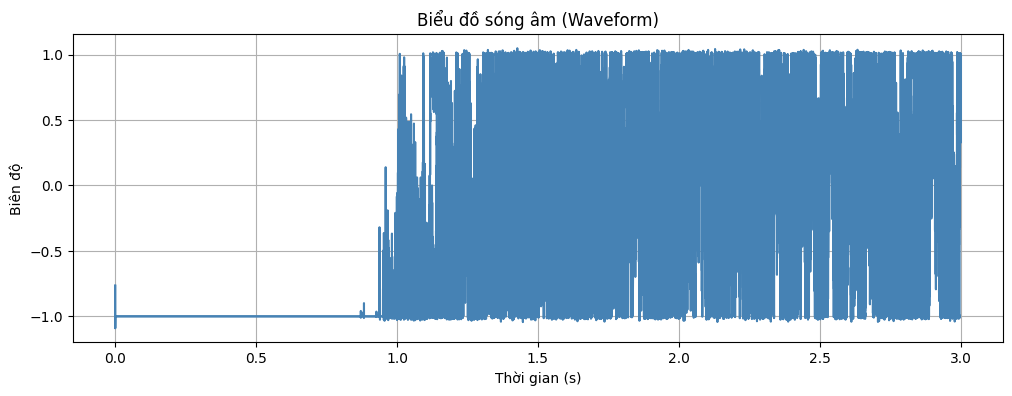

In [6]:
time = np.linspace(0, len(data) / fs, num=len(data))

# Vẽ sóng âm kênh trái
plt.figure(figsize=(12, 4))
plt.plot(time, data[:], color='steelblue')
plt.title("Biểu đồ sóng âm (Waveform)")
plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ")
plt.grid(True)
plt.show()

/tmp/ipykernel_33196/1297748060.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')


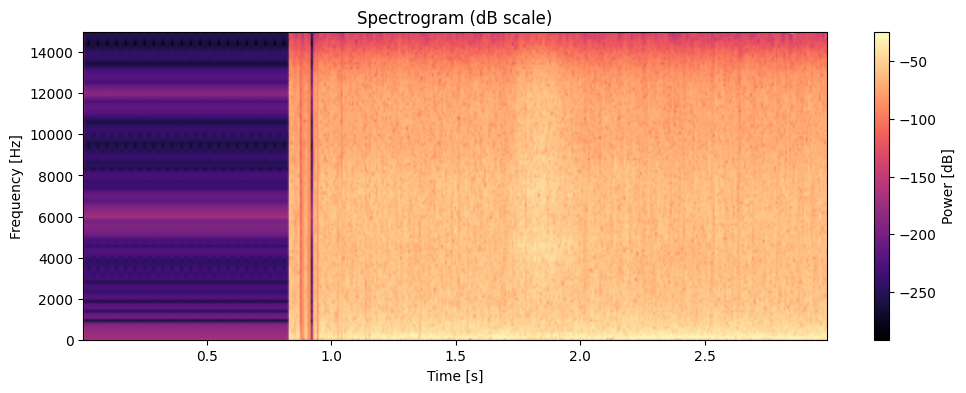

In [43]:
f, t, Sxx = spectrogram(data, fs=fs)
plt.figure(figsize=(12, 4))
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')
plt.title("Spectrogram (dB scale)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.colorbar(label='Power [dB]')
plt.show()